In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_parquet(r'yellow_tripdata_2026-05.parquet')
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-05-01 00:04:59,2026-05-01 00:32:48,1.0,7.51,1.0,N,138,37,2,35.9,6.00,0.5,0.00,0.0,1.0,45.40,0.0,2.0,0.00
1,2,2026-05-01 00:37:05,2026-05-01 00:59:47,1.0,6.14,1.0,N,138,237,1,27.5,6.00,0.5,9.56,0.0,1.0,49.81,2.5,2.0,0.75
2,1,2026-05-01 00:34:05,2026-05-01 00:54:02,1.0,2.40,1.0,N,249,232,1,19.1,4.25,0.5,3.73,0.0,1.0,28.58,2.5,0.0,0.75
3,1,2026-05-01 00:55:07,2026-05-01 01:02:43,0.0,1.20,1.0,N,232,114,1,9.3,4.25,0.5,3.00,0.0,1.0,18.05,2.5,0.0,0.75
4,7,2026-05-01 00:44:13,2026-05-01 00:44:13,2.0,0.86,1.0,N,140,237,1,7.2,0.00,0.5,2.44,0.0,1.0,14.64,2.5,0.0,0.00


In [3]:
df.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'Airport_fee',
       'cbd_congestion_fee'],
      dtype='str')

Predicting Time Taken by Taxi

In [4]:
tng = df[['tpep_pickup_datetime', 'passenger_count', 'trip_distance', 'PULocationID', 'DOLocationID', "RatecodeID", "fare_amount"]]
tng

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount
0,2026-05-01 00:04:59,1.0,7.51,138,37,1.0,35.90
1,2026-05-01 00:37:05,1.0,6.14,138,237,1.0,27.50
2,2026-05-01 00:34:05,1.0,2.40,249,232,1.0,19.10
3,2026-05-01 00:55:07,0.0,1.20,232,114,1.0,9.30
4,2026-05-01 00:44:13,2.0,0.86,140,237,1.0,7.20
...,...,...,...,...,...,...,...
4090831,2026-05-31 23:35:12,NaN,5.11,74,243,NaN,17.19
4090832,2026-05-31 23:48:01,NaN,8.80,129,130,NaN,27.98
4090833,2026-05-31 23:48:50,NaN,6.47,48,116,NaN,24.12
4090834,2026-05-31 23:23:13,NaN,2.94,113,256,NaN,18.20


In [5]:
tng["trip_duration_min"] = (
    df["tpep_dropoff_datetime"]
    - df["tpep_pickup_datetime"]
).dt.total_seconds() / 60

Removing Improbable Data

In [6]:
tng.describe()

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min
count,4090836,3.135465e+06,4.090836e+06,4.090836e+06,4.090836e+06,3.135465e+06,4.090836e+06,4.090836e+06
mean,2026-05-16 10:34:13.127794,1.243260e+00,4.954773e+00,1.621047e+02,1.618326e+02,5.495495e+00,2.151320e+01,1.877588e+01
min,2008-12-31 23:05:53,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,-9.500000e+02,0.000000e+00
25%,2026-05-08 21:15:44.750000,1.000000e+00,1.040000e+00,1.140000e+02,1.080000e+02,1.000000e+00,1.000000e+01,8.583333e+00
50%,2026-05-16 01:47:51,1.000000e+00,1.870000e+00,1.610000e+02,1.620000e+02,1.000000e+00,1.630000e+01,1.448333e+01
75%,2026-05-23 15:40:14.250000,1.000000e+00,3.810000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.680000e+01,2.326667e+01
max,2026-06-01 00:20:35,9.000000e+00,3.074915e+05,2.650000e+02,2.650000e+02,9.900000e+01,5.525990e+03,9.960150e+03
std,NaN,6.366766e-01,4.836157e+02,6.700297e+01,7.070912e+01,2.028825e+01,1.901303e+01,2.671057e+01


Use only 2026 Data

In [7]:
tng = tng[tng["tpep_pickup_datetime"].dt.year == 2026]
tng

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min
0,2026-05-01 00:04:59,1.0,7.51,138,37,1.0,35.90,27.816667
1,2026-05-01 00:37:05,1.0,6.14,138,237,1.0,27.50,22.700000
2,2026-05-01 00:34:05,1.0,2.40,249,232,1.0,19.10,19.950000
3,2026-05-01 00:55:07,0.0,1.20,232,114,1.0,9.30,7.600000
4,2026-05-01 00:44:13,2.0,0.86,140,237,1.0,7.20,0.000000
...,...,...,...,...,...,...,...,...
4090831,2026-05-31 23:35:12,NaN,5.11,74,243,NaN,17.19,15.866667
4090832,2026-05-31 23:48:01,NaN,8.80,129,130,NaN,27.98,17.933333
4090833,2026-05-31 23:48:50,NaN,6.47,48,116,NaN,24.12,15.033333
4090834,2026-05-31 23:23:13,NaN,2.94,113,256,NaN,18.20,15.366667


In [8]:
tng.isna().sum()

tpep_pickup_datetime         0
passenger_count         955371
trip_distance                0
PULocationID                 0
DOLocationID                 0
RatecodeID              955371
fare_amount                  0
trip_duration_min            0
dtype: int64

In [9]:
tng = tng.dropna()
tng

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min
0,2026-05-01 00:04:59,1.0,7.51,138,37,1.0,35.9,27.816667
1,2026-05-01 00:37:05,1.0,6.14,138,237,1.0,27.5,22.700000
2,2026-05-01 00:34:05,1.0,2.40,249,232,1.0,19.1,19.950000
3,2026-05-01 00:55:07,0.0,1.20,232,114,1.0,9.3,7.600000
4,2026-05-01 00:44:13,2.0,0.86,140,237,1.0,7.2,0.000000
...,...,...,...,...,...,...,...,...
3135460,2026-05-31 23:28:04,1.0,1.26,238,43,1.0,9.3,6.616667
3135461,2026-05-31 23:16:18,1.0,1.89,163,236,1.0,10.0,6.233333
3135462,2026-05-31 23:36:41,1.0,3.15,100,144,1.0,19.8,17.566667
3135463,2026-05-31 23:09:24,1.0,1.21,142,239,1.0,10.0,8.783333


In [10]:
tng["passenger_count"].value_counts(dropna=False).sort_index()

passenger_count
0.0      12533
1.0    2578716
2.0     395103
3.0      83959
4.0      52929
5.0       7666
6.0       4553
8.0          3
9.0          1
Name: count, dtype: int64

In [11]:
tng = tng[tng["passenger_count"] != 0]
tng

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min
0,2026-05-01 00:04:59,1.0,7.51,138,37,1.0,35.9,27.816667
1,2026-05-01 00:37:05,1.0,6.14,138,237,1.0,27.5,22.700000
2,2026-05-01 00:34:05,1.0,2.40,249,232,1.0,19.1,19.950000
4,2026-05-01 00:44:13,2.0,0.86,140,237,1.0,7.2,0.000000
5,2026-05-01 00:24:35,1.0,5.89,255,236,1.0,28.9,25.333333
...,...,...,...,...,...,...,...,...
3135460,2026-05-31 23:28:04,1.0,1.26,238,43,1.0,9.3,6.616667
3135461,2026-05-31 23:16:18,1.0,1.89,163,236,1.0,10.0,6.233333
3135462,2026-05-31 23:36:41,1.0,3.15,100,144,1.0,19.8,17.566667
3135463,2026-05-31 23:09:24,1.0,1.21,142,239,1.0,10.0,8.783333


In [12]:
tng["passenger_count"].value_counts(dropna=False).sort_index()

passenger_count
1.0    2578716
2.0     395103
3.0      83959
4.0      52929
5.0       7666
6.0       4553
8.0          3
9.0          1
Name: count, dtype: int64

C:\Users\Admin\AppData\Local\Temp\ipykernel_14548\2503514648.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axes[0].boxplot(tng["trip_distance"].dropna(), vert=False)


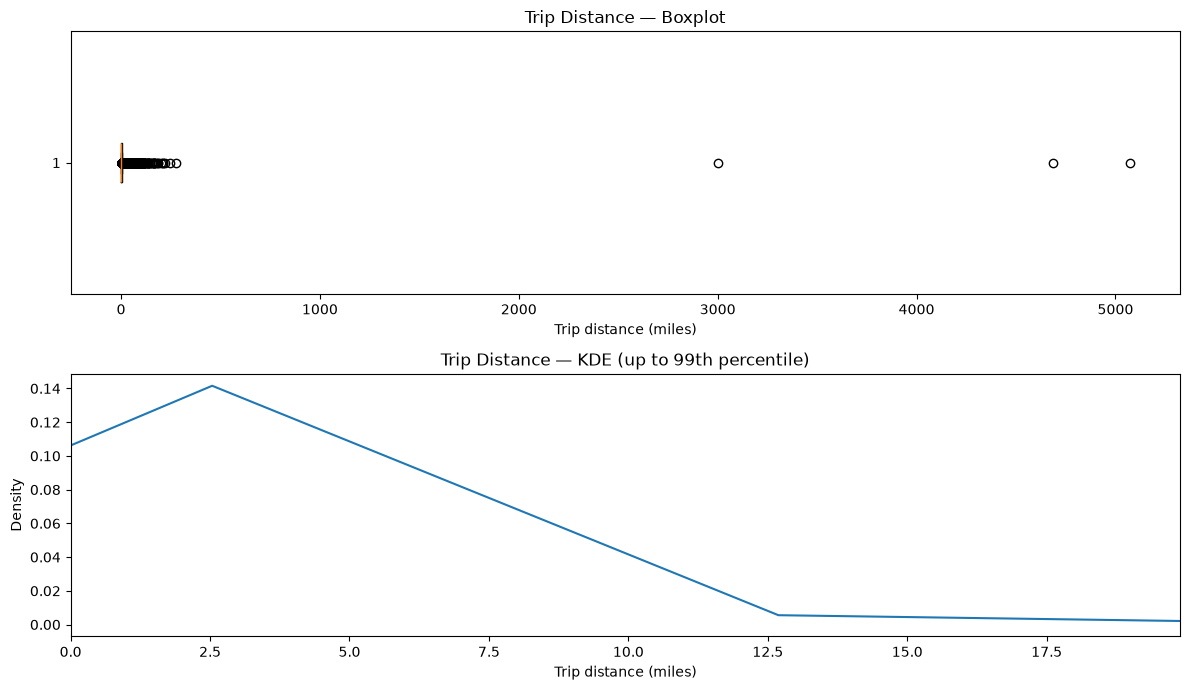

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7))

axes[0].boxplot(tng["trip_distance"].dropna(), vert=False)
axes[0].set_xlabel("Trip distance (miles)")
axes[0].set_title("Trip Distance — Boxplot")

tng["trip_distance"].plot.kde(ax=axes[1])
axes[1].set_xlim(0, tng["trip_distance"].quantile(0.99))
axes[1].set_xlabel("Trip distance (miles)")
axes[1].set_title("Trip Distance — KDE (up to 99th percentile)")

plt.tight_layout()
plt.show()

In [14]:
tng["trip_distance"].quantile(
    [0.95, 0.99, 0.995, 0.999, 0.9995, 1.0]
)

0.9500      14.250000
0.9900      19.890000
0.9950      21.940000
0.9990      30.670000
0.9995      36.475355
1.0000    5071.010000
Name: trip_distance, dtype: float64

In [15]:
cutoff = tng["trip_distance"].quantile(0.995)

print("99.5th percentile:", cutoff)
print("Trips above cutoff:", (tng["trip_distance"] > cutoff).sum())

99.5th percentile: 21.94
Trips above cutoff: 15613


In [16]:
tng = tng[
    (tng["trip_distance"] > 0) &
    (tng["trip_distance"] <= cutoff)
]
tng

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min
0,2026-05-01 00:04:59,1.0,7.51,138,37,1.0,35.9,27.816667
1,2026-05-01 00:37:05,1.0,6.14,138,237,1.0,27.5,22.700000
2,2026-05-01 00:34:05,1.0,2.40,249,232,1.0,19.1,19.950000
4,2026-05-01 00:44:13,2.0,0.86,140,237,1.0,7.2,0.000000
5,2026-05-01 00:24:35,1.0,5.89,255,236,1.0,28.9,25.333333
...,...,...,...,...,...,...,...,...
3135460,2026-05-31 23:28:04,1.0,1.26,238,43,1.0,9.3,6.616667
3135461,2026-05-31 23:16:18,1.0,1.89,163,236,1.0,10.0,6.233333
3135462,2026-05-31 23:36:41,1.0,3.15,100,144,1.0,19.8,17.566667
3135463,2026-05-31 23:09:24,1.0,1.21,142,239,1.0,10.0,8.783333


In [17]:
tng.describe()

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min
count,3070701,3.070701e+06,3.070701e+06,3.070701e+06,3.070701e+06,3.070701e+06,3.070701e+06,3.070701e+06
mean,2026-05-16 05:27:43.387618,1.246365e+00,3.299566e+00,1.654794e+02,1.649419e+02,5.465660e+00,1.964231e+01,1.850144e+01
min,2026-04-30 23:47:18,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,-8.880000e+02,0.000000e+00
25%,2026-05-08 15:44:28,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,7.900000e+00
50%,2026-05-15 19:31:22,1.000000e+00,1.700000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.420000e+01,1.343333e+01
75%,2026-05-23 10:15:30,1.000000e+00,3.370000e+00,2.340000e+02,2.350000e+02,1.000000e+00,2.330000e+01,2.258333e+01
max,2026-06-01 00:20:35,8.000000e+00,2.194000e+01,2.650000e+02,2.650000e+02,9.900000e+01,5.525990e+03,6.082467e+03
std,NaN,6.295955e-01,4.088852e+00,6.418832e+01,6.941157e+01,2.027593e+01,1.744575e+01,2.746761e+01


In [18]:
tng["trip_duration_min"].describe(
    percentiles=[0.95, 0.99, 0.995, 0.999, 0.9995, 1.0]
)

count     3.070701e+06
mean      1.850144e+01
std       2.746761e+01
min       0.000000e+00
95%       5.101667e+01
99%       8.191667e+01
99.5%     9.453333e+01
99.9%     1.300167e+02
99.95%    1.570717e+02
100%      6.082467e+03
max       6.082467e+03
Name: trip_duration_min, dtype: float64

In [19]:
DURATION_PERCENTILE = 0.995

duration_cutoff = tng["trip_duration_min"].quantile(
    DURATION_PERCENTILE
)

print("99.5th percentile:", duration_cutoff)
print(
    "Trips above cutoff:",
    (tng["trip_duration_min"] > duration_cutoff).sum()
)

99.5th percentile: 94.53333333333333
Trips above cutoff: 15341


In [20]:
tng = tng[
    tng["trip_duration_min"] <= duration_cutoff
]

In [21]:
tng.describe()

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min
count,3055360,3.055360e+06,3.055360e+06,3.055360e+06,3.055360e+06,3.055360e+06,3.055360e+06,3.055360e+06
mean,2026-05-16 05:30:53.173201,1.246866e+00,3.244193e+00,1.656406e+02,1.650926e+02,5.136382e+00,1.946915e+01,1.769087e+01
min,2026-04-30 23:47:18,1.000000e+00,1.000000e-02,1.000000e+00,1.000000e+00,1.000000e+00,-8.880000e+02,0.000000e+00
25%,2026-05-08 15:44:33,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,7.866667e+00
50%,2026-05-15 19:35:32.500000,1.000000e+00,1.700000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.420000e+01,1.336667e+01
75%,2026-05-23 10:36:29,1.000000e+00,3.310000e+00,2.340000e+02,2.360000e+02,1.000000e+00,2.260000e+01,2.238333e+01
max,2026-05-31 23:59:59,8.000000e+00,2.194000e+01,2.650000e+02,2.650000e+02,9.900000e+01,5.525990e+03,9.453333e+01
std,NaN,6.299082e-01,4.008428e+00,6.413091e+01,6.935884e+01,1.953839e+01,1.721966e+01,1.484242e+01


In [22]:
tng["pickup_hour_sin"] = np.sin(
    2 * np.pi * tng["tpep_pickup_datetime"].dt.hour / 24
)

tng["pickup_hour_cos"] = np.cos(
    2 * np.pi * tng["tpep_pickup_datetime"].dt.hour / 24
)

tng

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min,pickup_hour_sin,pickup_hour_cos
0,2026-05-01 00:04:59,1.0,7.51,138,37,1.0,35.9,27.816667,0.000000,1.000000
1,2026-05-01 00:37:05,1.0,6.14,138,237,1.0,27.5,22.700000,0.000000,1.000000
2,2026-05-01 00:34:05,1.0,2.40,249,232,1.0,19.1,19.950000,0.000000,1.000000
4,2026-05-01 00:44:13,2.0,0.86,140,237,1.0,7.2,0.000000,0.000000,1.000000
5,2026-05-01 00:24:35,1.0,5.89,255,236,1.0,28.9,25.333333,0.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...
3135460,2026-05-31 23:28:04,1.0,1.26,238,43,1.0,9.3,6.616667,-0.258819,0.965926
3135461,2026-05-31 23:16:18,1.0,1.89,163,236,1.0,10.0,6.233333,-0.258819,0.965926
3135462,2026-05-31 23:36:41,1.0,3.15,100,144,1.0,19.8,17.566667,-0.258819,0.965926
3135463,2026-05-31 23:09:24,1.0,1.21,142,239,1.0,10.0,8.783333,-0.258819,0.965926


In [23]:
tng["pickup_dayofweek"] = tng["tpep_pickup_datetime"].dt.dayofweek
tng

,tpep_pickup_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,RatecodeID,fare_amount,trip_duration_min,pickup_hour_sin,pickup_hour_cos,pickup_dayofweek
0,2026-05-01 00:04:59,1.0,7.51,138,37,1.0,35.9,27.816667,0.000000,1.000000,4
1,2026-05-01 00:37:05,1.0,6.14,138,237,1.0,27.5,22.700000,0.000000,1.000000,4
2,2026-05-01 00:34:05,1.0,2.40,249,232,1.0,19.1,19.950000,0.000000,1.000000,4
4,2026-05-01 00:44:13,2.0,0.86,140,237,1.0,7.2,0.000000,0.000000,1.000000,4
5,2026-05-01 00:24:35,1.0,5.89,255,236,1.0,28.9,25.333333,0.000000,1.000000,4
...,...,...,...,...,...,...,...,...,...,...,...
3135460,2026-05-31 23:28:04,1.0,1.26,238,43,1.0,9.3,6.616667,-0.258819,0.965926,6
3135461,2026-05-31 23:16:18,1.0,1.89,163,236,1.0,10.0,6.233333,-0.258819,0.965926,6
3135462,2026-05-31 23:36:41,1.0,3.15,100,144,1.0,19.8,17.566667,-0.258819,0.965926,6
3135463,2026-05-31 23:09:24,1.0,1.21,142,239,1.0,10.0,8.783333,-0.258819,0.965926,6


In [24]:
tng["tpep_pickup_datetime"] = pd.to_datetime(
    tng["tpep_pickup_datetime"]
)

train = tng[
    tng["tpep_pickup_datetime"] < "2026-05-22"
]

val = tng[
    (tng["tpep_pickup_datetime"] >= "2026-05-22") &
    (tng["tpep_pickup_datetime"] < "2026-05-26")
]

test = tng[
    tng["tpep_pickup_datetime"] >= "2026-05-26"
]

In [25]:
print("Train:", train.shape)
print("Val:", val.shape)
print("Test:", test.shape)

print("\nTrain:", train["tpep_pickup_datetime"].min(),
      "→", train["tpep_pickup_datetime"].max())

print("Val:", val["tpep_pickup_datetime"].min(),
      "→", val["tpep_pickup_datetime"].max())

print("Test:", test["tpep_pickup_datetime"].min(),
      "→", test["tpep_pickup_datetime"].max())

Train: (2184233, 11)
Val: (294446, 11)
Test: (576681, 11)

Train: 2026-04-30 23:47:18 → 2026-05-21 23:59:59
Val: 2026-05-22 00:00:00 → 2026-05-25 23:59:59
Test: 2026-05-26 00:00:00 → 2026-05-31 23:59:59


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBRegressor

In [27]:
features = [
    "PULocationID",
    "DOLocationID",
    "passenger_count",
    "RatecodeID",
    "pickup_hour_sin",
    "pickup_hour_cos",
    "pickup_dayofweek",
]

In [28]:
print(train[features].isna().sum())
print(train[features].dtypes)

PULocationID        0
DOLocationID        0
passenger_count     0
RatecodeID          0
pickup_hour_sin     0
pickup_hour_cos     0
pickup_dayofweek    0
dtype: int64
PULocationID          int32
DOLocationID          int32
passenger_count     float64
RatecodeID          float64
pickup_hour_sin     float64
pickup_hour_cos     float64
pickup_dayofweek      int32
dtype: object


In [29]:
print(val[features].isna().sum())
print(val[features].dtypes)

PULocationID        0
DOLocationID        0
passenger_count     0
RatecodeID          0
pickup_hour_sin     0
pickup_hour_cos     0
pickup_dayofweek    0
dtype: int64
PULocationID          int32
DOLocationID          int32
passenger_count     float64
RatecodeID          float64
pickup_hour_sin     float64
pickup_hour_cos     float64
pickup_dayofweek      int32
dtype: object


In [30]:
print(test[features].isna().sum())
print(test[features].dtypes)

PULocationID        0
DOLocationID        0
passenger_count     0
RatecodeID          0
pickup_hour_sin     0
pickup_hour_cos     0
pickup_dayofweek    0
dtype: int64
PULocationID          int32
DOLocationID          int32
passenger_count     float64
RatecodeID          float64
pickup_hour_sin     float64
pickup_hour_cos     float64
pickup_dayofweek      int32
dtype: object


In [31]:
X_train = train[features]
y_train_duration = train["trip_duration_min"]

X_val = val[features]
y_val_duration = val["trip_duration_min"]

X_test = test[features]
y_test_duration = test["trip_duration_min"]

In [32]:
duration_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1
)

In [33]:
duration_model.fit(
    X_train,
    y_train_duration,
    eval_set=[
        (X_train, y_train_duration),
        (X_val, y_val_duration)
    ],
    verbose=50
)

[0]	validation_0-mae:10.54568	validation_1-mae:9.60250
[50]	validation_0-mae:6.75307	validation_1-mae:6.48818
[100]	validation_0-mae:6.42079	validation_1-mae:6.24451
[150]	validation_0-mae:6.06735	validation_1-mae:5.98424
[200]	validation_0-mae:5.84202	validation_1-mae:5.83158
[250]	validation_0-mae:5.61746	validation_1-mae:5.68323
[300]	validation_0-mae:5.48437	validation_1-mae:5.60592
[350]	validation_0-mae:5.40082	validation_1-mae:5.55798
[400]	validation_0-mae:5.30600	validation_1-mae:5.50166
[450]	validation_0-mae:5.22246	validation_1-mae:5.45506
[499]	validation_0-mae:5.17585	validation_1-mae:5.43428


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [34]:
duration_val_pred = duration_model.predict(X_val)
duration_test_pred = duration_model.predict(X_test)

In [35]:
def evaluate_regression(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred)
    }

In [36]:
duration_val_scores = evaluate_regression(
    y_val_duration,
    duration_val_pred
)

duration_test_scores = evaluate_regression(
    y_test_duration,
    duration_test_pred
)

print("Duration - Validation")
for metric, value in duration_val_scores.items():
    print(f"{metric}: {value:.4f}")

print("\nDuration - Test")
for metric, value in duration_test_scores.items():
    print(f"{metric}: {value:.4f}")

Duration - Validation
MAE: 5.4343
RMSE: 8.0171
R2: 0.5892

Duration - Test
MAE: 5.2649
RMSE: 7.8383
R2: 0.7069


Predicting Fare

In [37]:
X_train = train[features]
y_train_fare = train["fare_amount"]

X_val = val[features]
y_val_fare = val["fare_amount"]

X_test = test[features]
y_test_fare = test["fare_amount"]

In [38]:
fare_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    eval_metric="mae",
    random_state=42,
    n_jobs=-1
)

In [39]:
fare_model.fit(
    X_train,
    y_train_fare,
    eval_set=[
        (X_train, y_train_fare),
        (X_val, y_val_fare)
    ],
    verbose=50
)

[0]	validation_0-mae:10.90985	validation_1-mae:11.54178
[50]	validation_0-mae:5.58714	validation_1-mae:5.56469
[100]	validation_0-mae:5.24627	validation_1-mae:5.23843
[150]	validation_0-mae:4.91109	validation_1-mae:4.94307
[200]	validation_0-mae:4.78212	validation_1-mae:4.83482
[250]	validation_0-mae:4.61812	validation_1-mae:4.69454
[300]	validation_0-mae:4.49834	validation_1-mae:4.59312
[350]	validation_0-mae:4.41615	validation_1-mae:4.52781
[400]	validation_0-mae:4.31858	validation_1-mae:4.45109
[450]	validation_0-mae:4.25826	validation_1-mae:4.40336
[499]	validation_0-mae:4.22219	validation_1-mae:4.37864


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'mae'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [40]:
fare_val_pred = fare_model.predict(X_val)
fare_test_pred = fare_model.predict(X_test)

In [41]:
fare_val_scores = evaluate_regression(
    y_val_fare,
    fare_val_pred
)

fare_test_scores = evaluate_regression(
    y_test_fare,
    fare_test_pred
)

print("Fare - Validation")
for metric, value in fare_val_scores.items():
    print(f"{metric}: {value:.4f}")

print("\nFare - Test")
for metric, value in fare_test_scores.items():
    print(f"{metric}: {value:.4f}")

Fare - Validation
MAE: 4.3786
RMSE: 12.9702
R2: 0.5800

Fare - Test
MAE: 4.2869
RMSE: 8.0368
R2: 0.7637


In [42]:
import joblib


joblib.dump(duration_model, "duration_model.joblib")
joblib.dump(fare_model, "fare_model.joblib")

['fare_model.joblib']

In [ ]:
duration_model = joblib.load("duration_model.joblib")
fare_model = joblib.load("fare_model.joblib")

print("Duration model:")
print(duration_model.feature_names_in_)

print("\nFare model:")
print(fare_model.feature_names_in_)

Duration model:
['PULocationID' 'DOLocationID' 'passenger_count' 'RatecodeID'
 'pickup_hour_sin' 'pickup_hour_cos' 'pickup_dayofweek']

Fare model:
['PULocationID' 'DOLocationID' 'passenger_count' 'RatecodeID'
 'pickup_hour_sin' 'pickup_hour_cos' 'pickup_dayofweek']
